# COMMEMI 2D-1：静位移下 OT vs MSE 反演对比

使用 `MT2DTrueModels.create_commemi_2d1` 生成标准模型，在合成数据上施加静位移后，
分别用 **6D OT**（`mode="6dot"`）与 **MSE**（`mode="mse"`）反演，并对比收敛曲线与视电阻率拟合。

In [1]:
import os
import sys
import torch
from pathlib import Path
import numpy as np

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "mt2d_inv" / "__init__.py").is_file():
            return p
    raise RuntimeError("Cannot find project root (expected src/mt2d_inv/__init__.py)")

root_path = str(_find_project_root(Path.cwd()))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

from src.mt2d_inv import MT2DInverterWeightedCost, MT2DTrueModels
from src.mt2d_inv.io import ExperimentLogger
from src.mt2d_inv.plotting import (
    plot_ot_mse_convergence,
    plot_ot_mse_convergence_from_dirs,
    plot_rho_fitting_from_npz,
    plot_ot_mse_pseudosection_from_npz,
)

logger = ExperimentLogger(
    model_tag="ccmm2d1",
    output_root=Path("test_results"),
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")
print(f"Project root: {root_path}")

Running on cuda
Project root: /home/liuxr/MTinv_OT3


In [2]:
import os
from pathlib import Path

print(f"当前目录: {Path.cwd()}")
print(f"目录内容: {list(Path.cwd().iterdir())}")

# 检查 src 在哪里
for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (p / "src").exists():
        print(f"找到 src 在: {p}")

当前目录: /home/liuxr/MTinv_OT3/tests/synthetic
目录内容: [PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/rubic_ot_21.ipynb'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/.ipynb_checkpoints'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/commemi_2d1_21_shift0.15.ipynb'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/commemi_2d1_21_shift0.ipynb'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/commemi_2d4_21_shift0.ipynb'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/test_results'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/commemi_2d1_21_shift0.1.ipynb'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/rubic_mse_21.ipynb'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/commemi_2d4_21_shift0.15.ipynb'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/commemi_2d4_21_shift0.1.ipynb')]
找到 src 在: /home/liuxr/MTinv_OT3


In [3]:
# 1) Build COMMEMI 2D-i true model
yn, zn, nza, sig_true = MT2DTrueModels.create_commemi_2d1(
    zn=None,
    yn=None,
    nza=10,
    device=device,
    rho_host=100.0,
    rho_block=10.0,
    y_half_width_m=2000.0,
    z_top_m=10000.0,
    z_bottom_m=30000.0,
)

# 2) Survey setup
freqs = torch.logspace(0, -5, 30, device=device)
stations = torch.linspace(-15000.0, 15000.0, 21, device=device)

print(f"Grid (nz, ny): {(len(zn)-1, len(yn)-1)}")
print(f"Stations: {len(stations)}, Freqs: {len(freqs)}")

Grid (nz, ny): (40, 40)
Stations: 21, Freqs: 30


✓ Random seed set: 123
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
Generating 2D MT synthetic data...
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ 2D data error propagation completed
Computing data weights (Target Noise: 1.0%)
  - Resistivity Error Floor: 1.0%
  - Phase Error Floor:       0.500 deg
✓ MSE data weights normalized (mean): scale=5.846255e+01
✓ Synthetic data generated
  -> Impedance noise level: 1.0% (gaussian)
✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


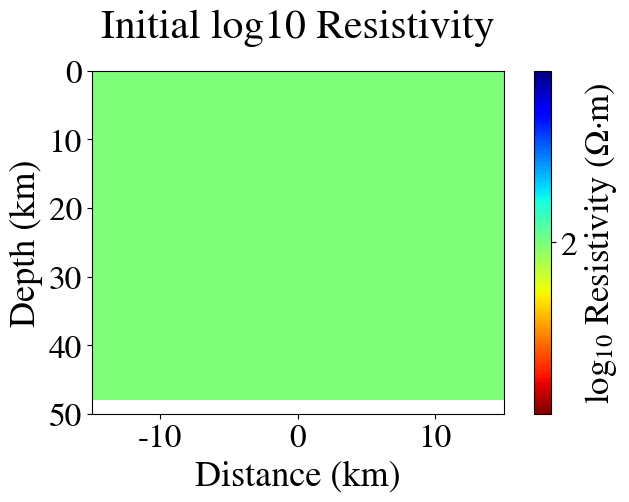

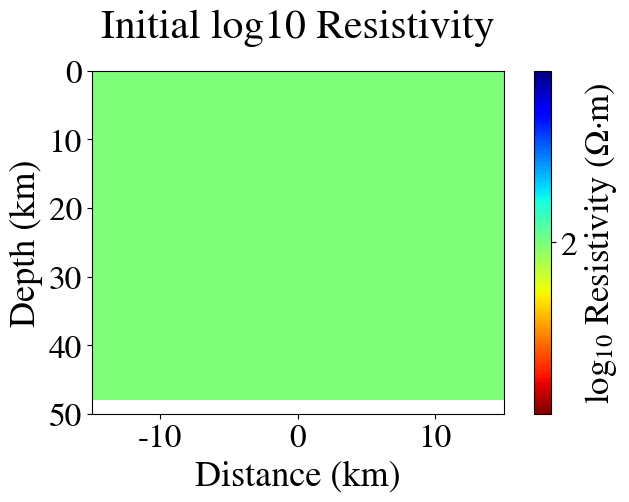

In [4]:
# 3) Inverter + synthetic data
inv = MT2DInverterWeightedCost(
    yn=torch.tensor(yn, dtype=torch.float64, device=device),
    zn=torch.tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs,
    stations=stations,
    device=device,
    random_seed=123,
    te_weight=1.0,
    tm_weight=1.0,
    data_loss_scale=10,
)
inv.set_forward_operator()
inv.sig_true = sig_true
inv.create_synthetic_data(noise_level=0.01,
                        noise_type="gaussian",
                        static_shift_std=0.15,   # 0.15 会导致电阻率发生约半个量级的剧烈上下平移
                        shift_modes=("xy", "yx"),# 作用于双极化模式 (TM 模式通常对畸变最敏感)
                        shift_stations="random",
                        shift_ratio =0.15)
inv.initialize_model(initial_sigma=0.01)
inv.plot_initial_model(clip_to_stations=True, ylim=[50, 0],synthetic_figwidth_scale=2.0)

In [5]:
# 4a) OT 反演 (6dot)
inv.initialize_model(initial_sigma=0.01)
final_sigma_ot = inv.run_inversion(
    n_epochs=300,
    mode="6dot",
    progress_interval=20,
    current_lambda=0.01,
    use_adaptive_lambda=True,
    lr=0.03,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing=False,
)
print("OT inversion done")
print(final_sigma_ot.min().item(), final_sigma_ot.max().item())

✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
Epoch 1/300 [   0.3%]
  Elapsed: 0:00:02 | Remaining: ~0:08:05 | ETA: 13:04:12
  Epoch time: 1.62s | Avg: 1.62s
  Total: 1.2354e-02 | Data(6dot): 1.2354e-02
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 10.475 | Rough: 0.00e+00 | Lam: 0.0100000
  OT-distance(6D, view-only): 1.235371e-02
  GradNorms: |g_d|=nan | |λ·g_m|=nan
 [Auto-Lambda] Epoch 10: Adjusted 1.00e-02 -> 1.41e-03 (ratio=2.002e-02)
 [Auto-Lambda] Epoch 20: Adjusted 1.41e-03 -> 3.38e-04 (ratio=5.722e-02)
Epoch 21/300 [   7.0%]
  Elapsed: 0:00:36 | Remaining: ~0:07:58 | ETA: 13:04:39
  Epoch time: 2.13s | Avg: 1.71s
  Total: 6.6962e-03 | Data(6dot): 6.3815e-03
  Misfit(RMS χ²): 9.690 | Rough: 9.30e-01 | Lam: 0.0003385
  OT-distance(6D, view-only): 6.381470e-03
  GradNorms: |g_d|=2.220e-05 | |λ·g_m|=4.966e-0

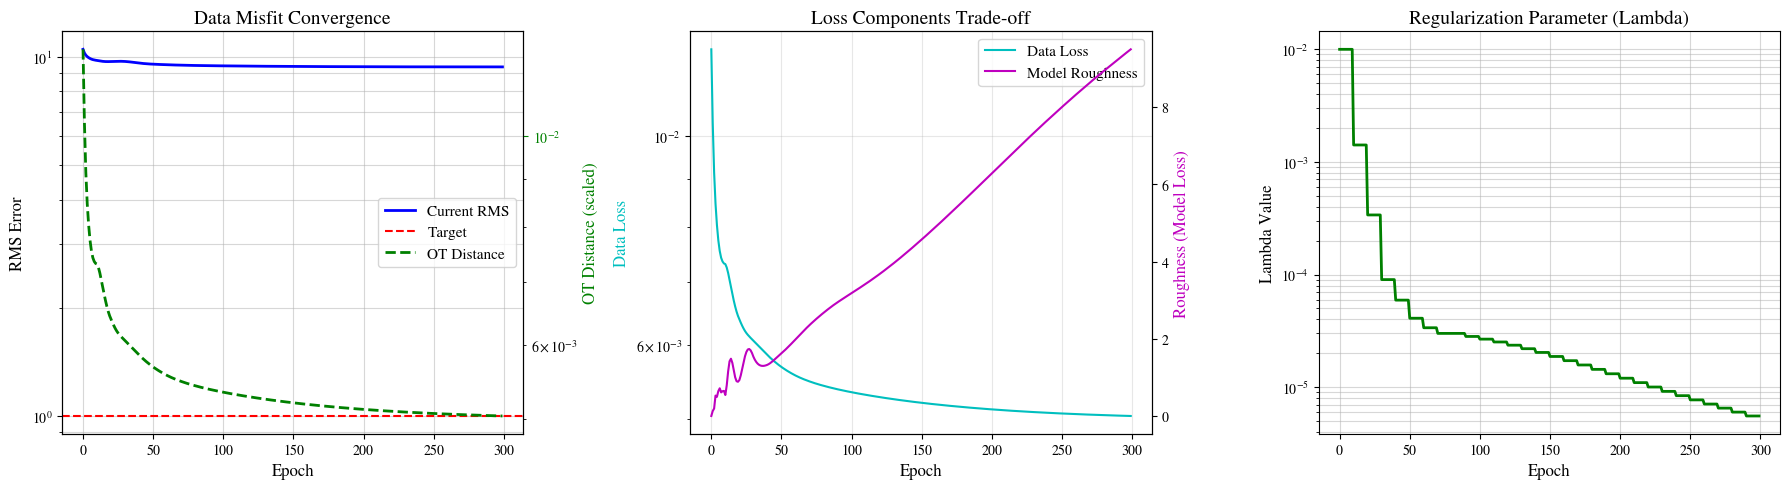

Model structural similarity (SSIM): 0.9434


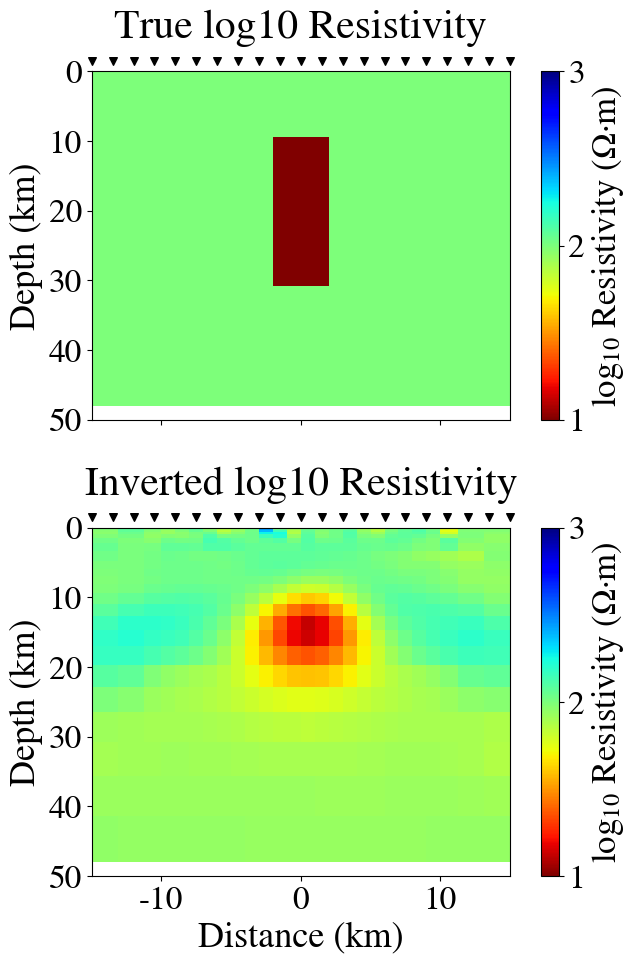

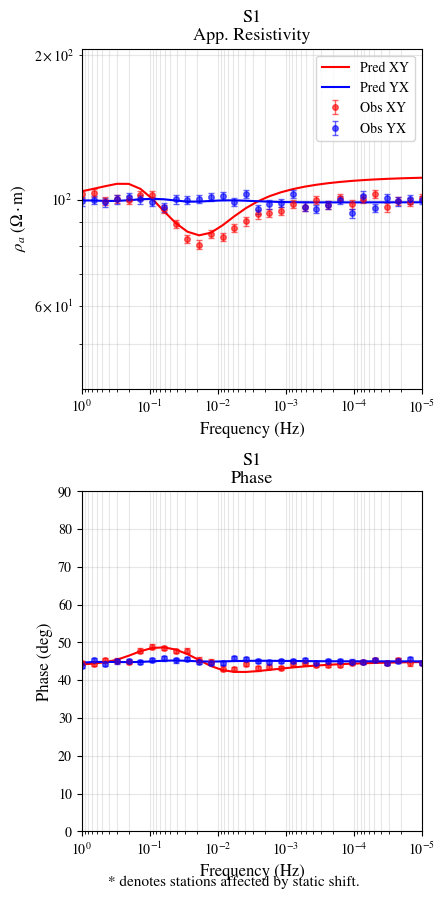

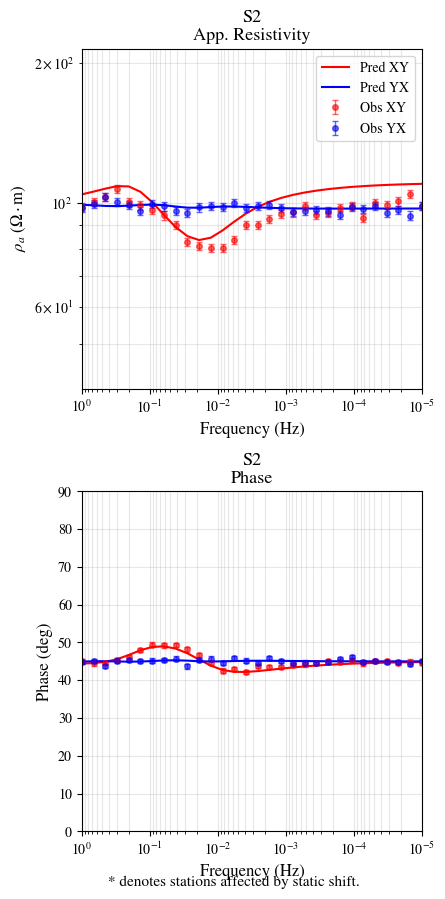

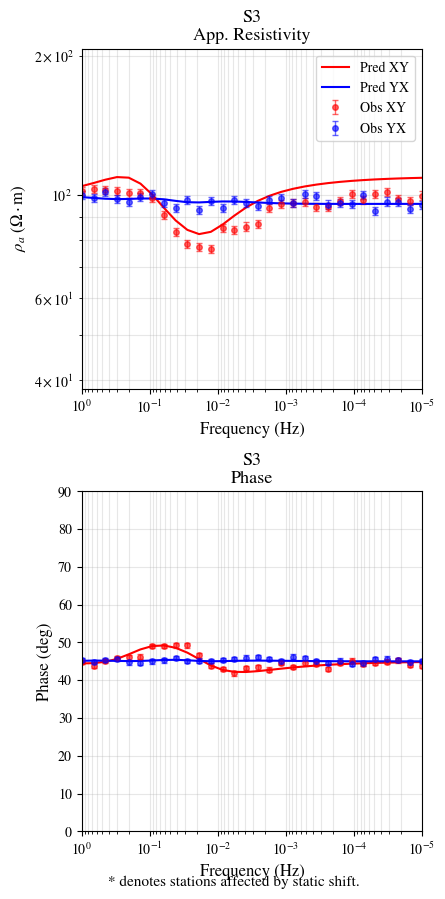

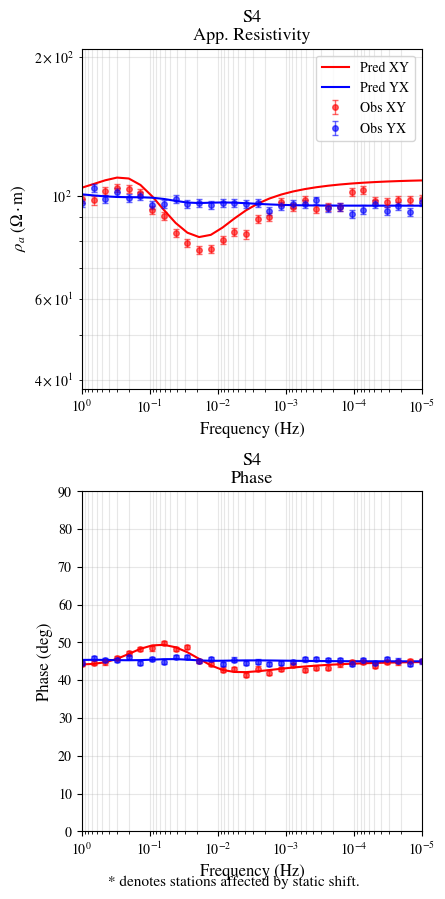

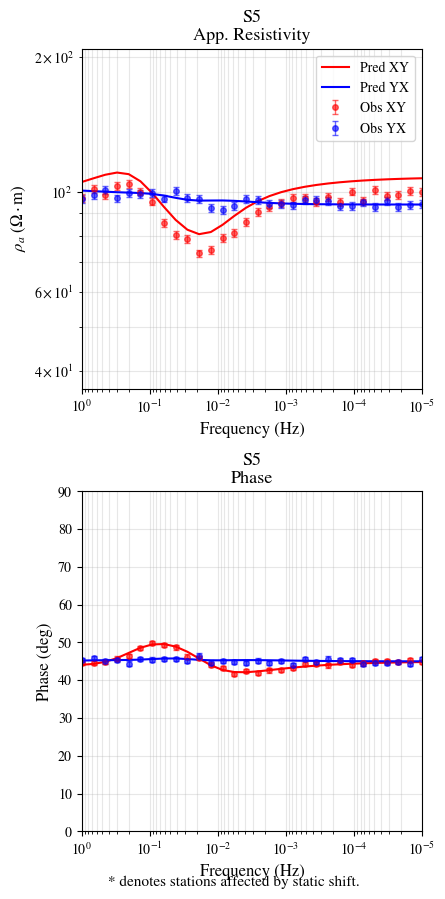

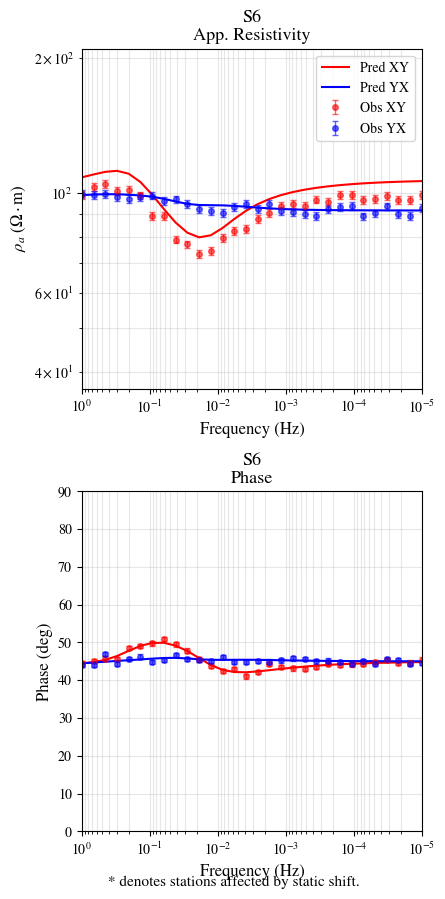

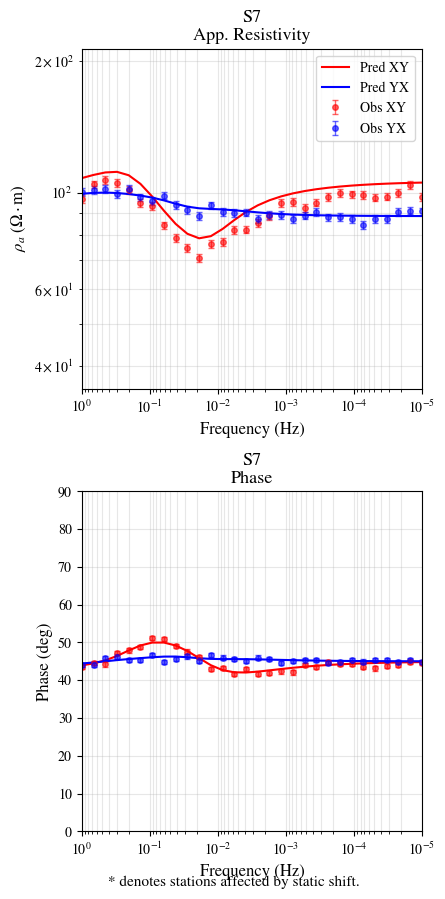

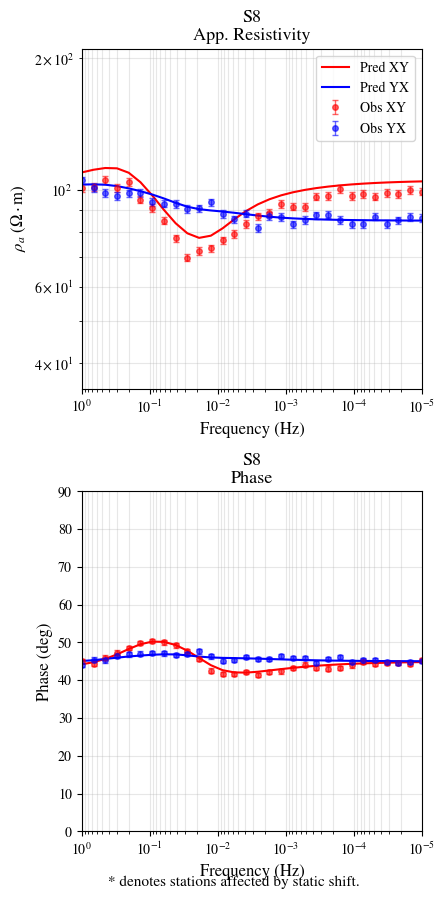

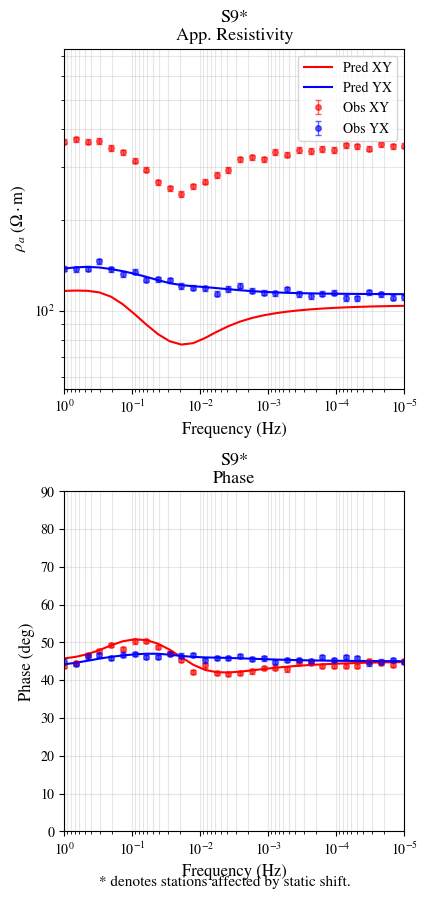

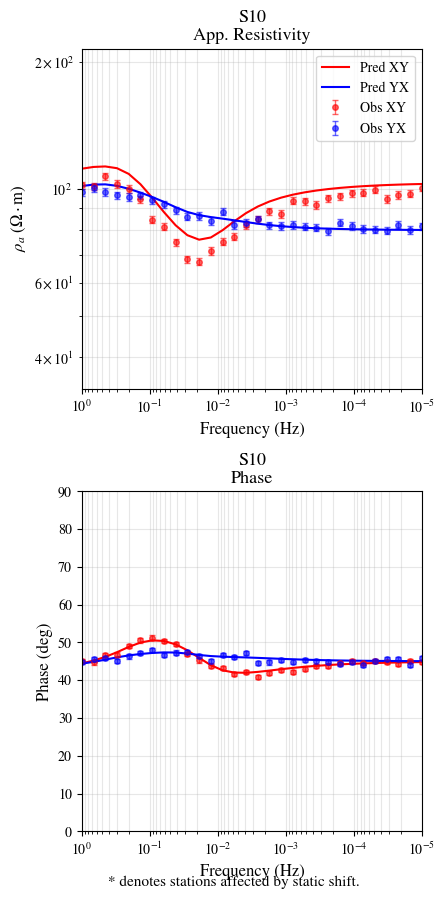

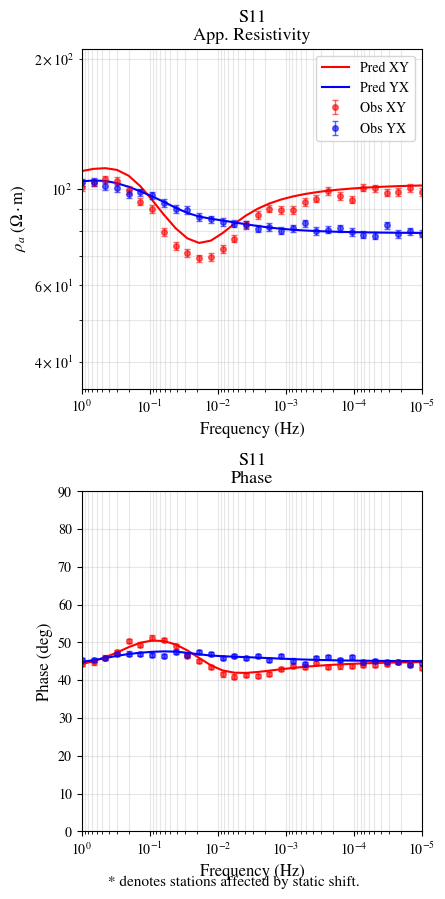

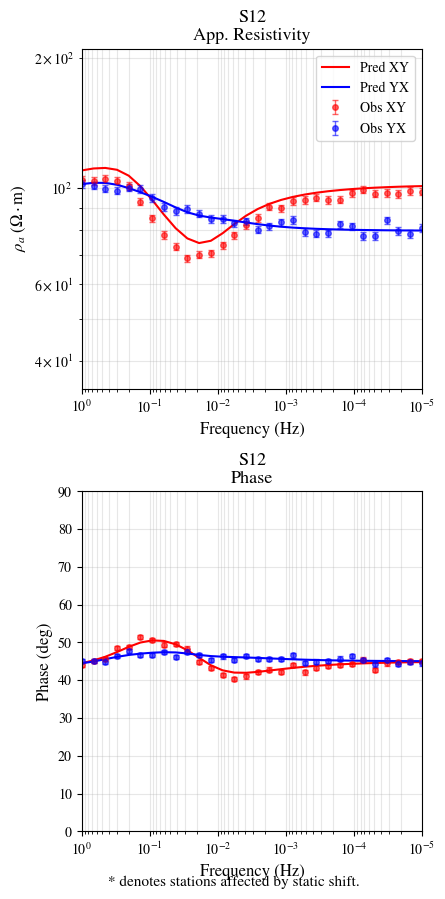

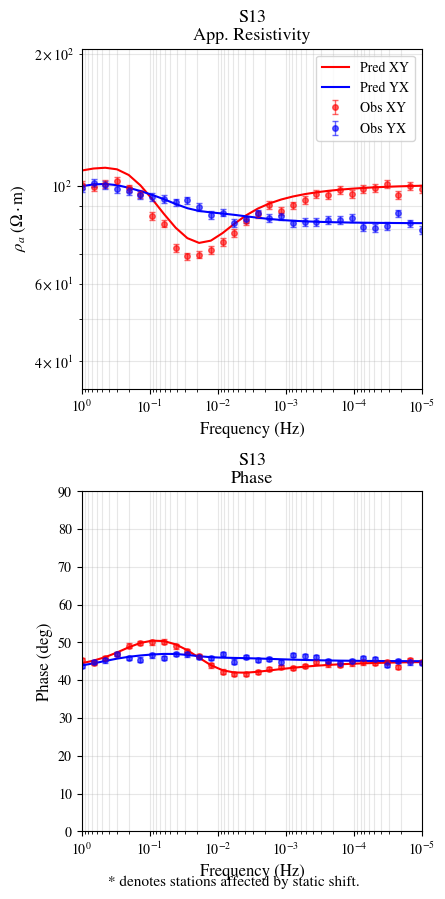

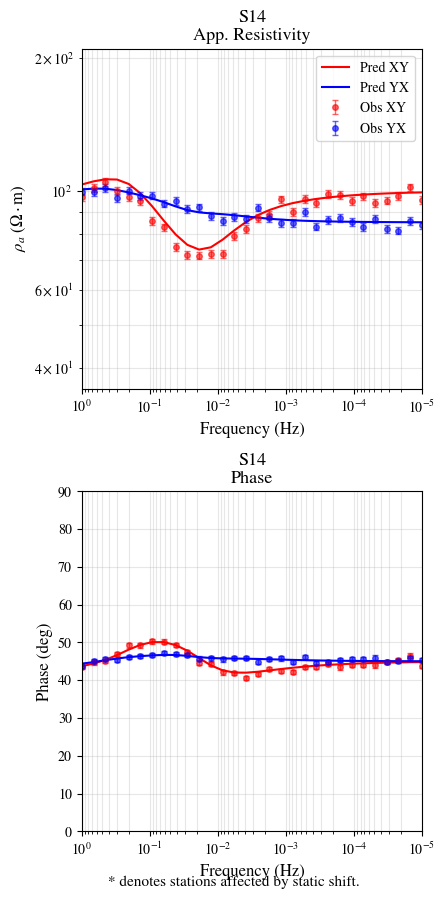

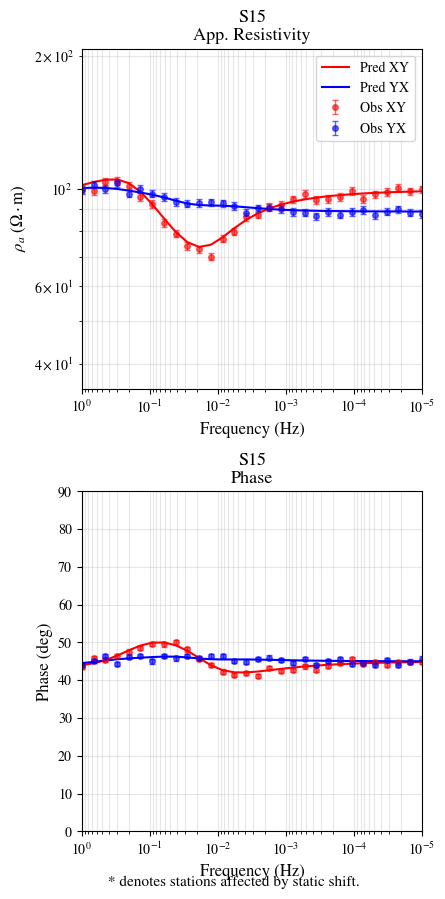

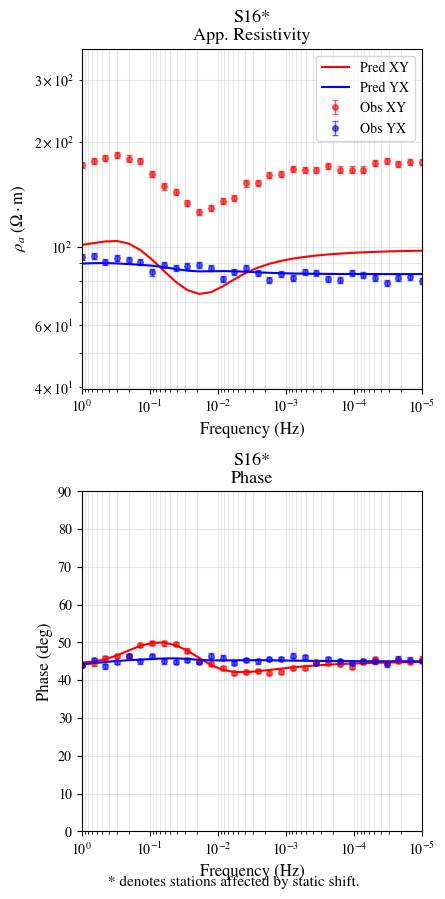

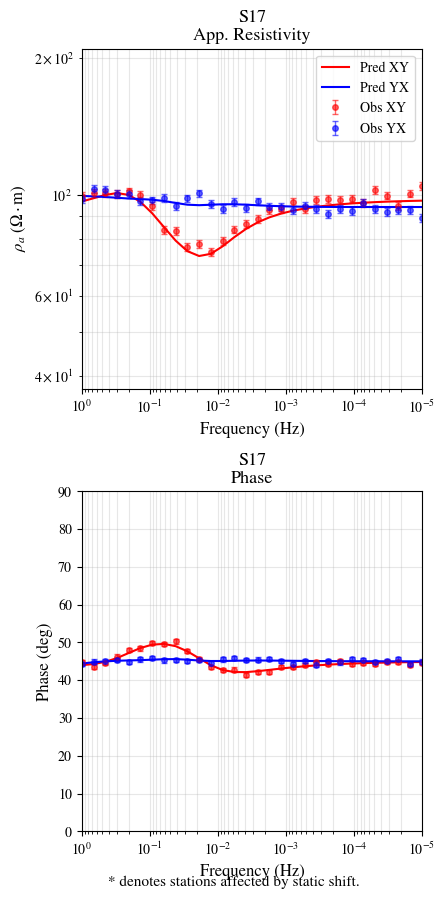

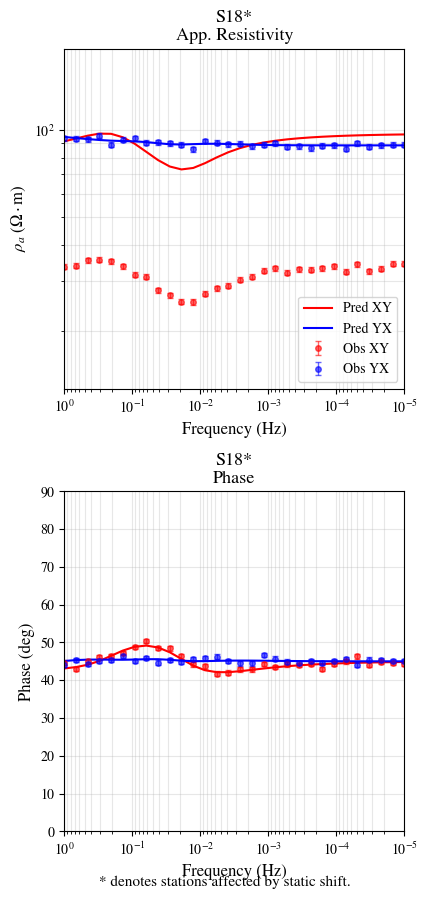

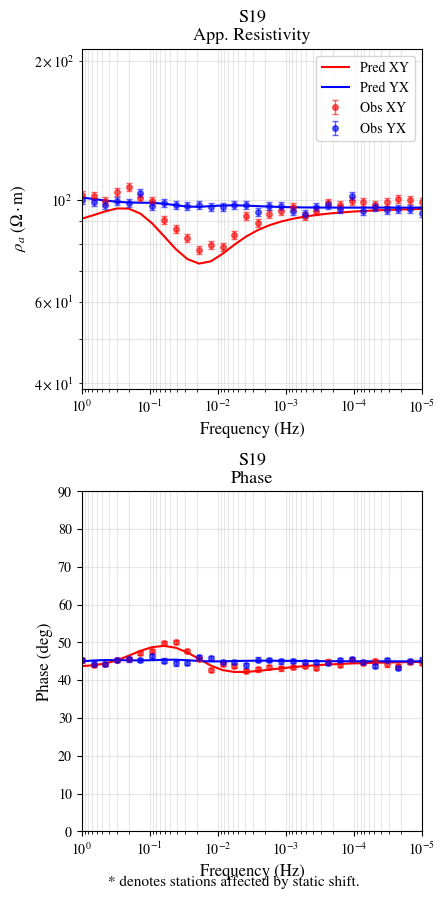

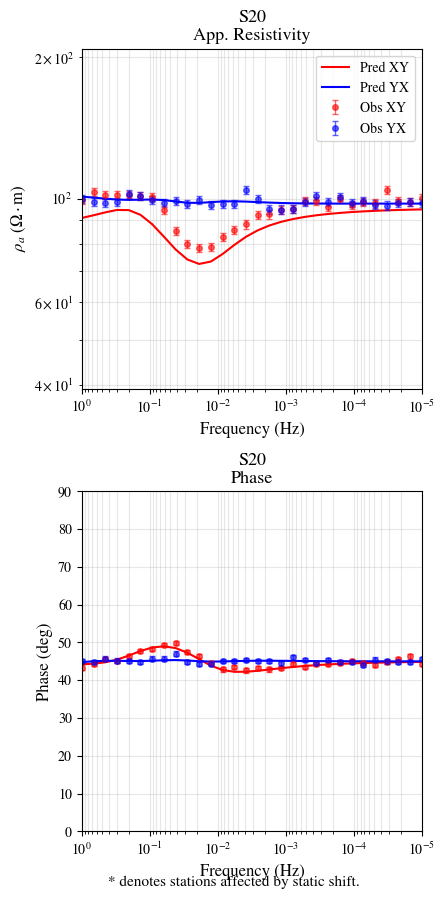

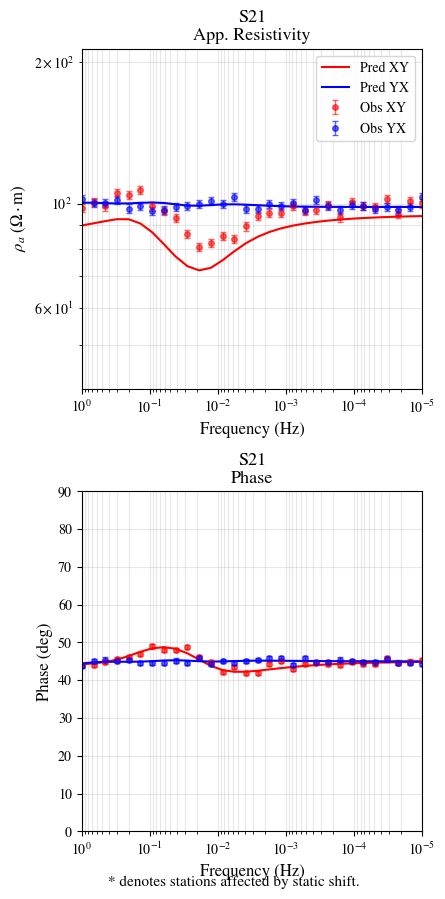

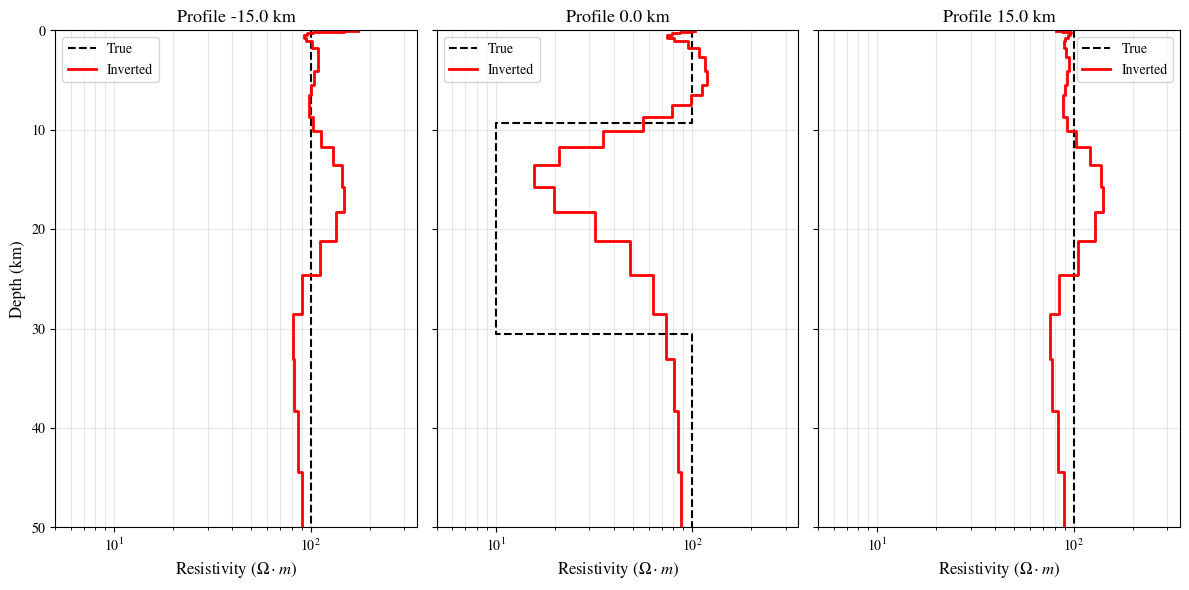

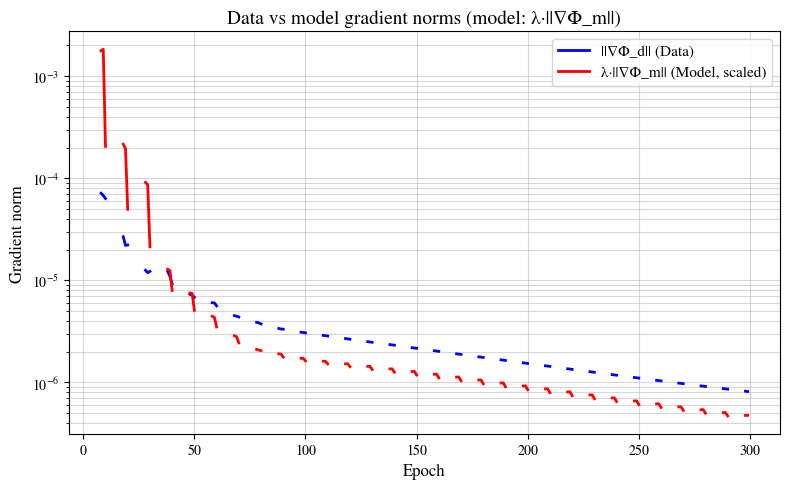

In [6]:
# 5a) OT 结果绘图
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)
inv.plot_data_fitting()
inv.plot_1d_profiles(depth_limit_km=50)
inv.plot_gradient_history()

In [7]:
# 6a) 保存 OT 结果
ot_run_dir = logger.save_from_inverter(inv, run_name="ot_21_1shift0.15")
history_ot = list(inv.loss_history)
print(f"OT run saved: {ot_run_dir}")


Saving results to: test_results/ccmm2d1/2026-07-06_13-05-08_ot_21_1shift0.15
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz
Model structural similarity (SSIM): 0.9434


/home/liuxr/MTinv_OT3/src/mt2d_inv/plotting/inversion.py:682: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


  ✓ data_fitting: 21 plots saved to test_results/ccmm2d1/2026-07-06_13-05-08_ot_21_1shift0.15/figures/data_fitting (21 stations)
  ✓ Figures saved to test_results/ccmm2d1/2026-07-06_13-05-08_ot_21_1shift0.15/figures

Results saved successfully!
  Location: test_results/ccmm2d1/2026-07-06_13-05-08_ot_21_1shift0.15
  Final RMS χ²: 9.3594
  RMSE: 0.1458
  MAPE: 5.33%

OT run saved: test_results/ccmm2d1/2026-07-06_13-05-08_ot_21_1shift0.15


In [8]:
# 4b) MSE 反演（同一静位移观测数据，重置初模）
inv.initialize_model(initial_sigma=0.01)
final_sigma_mse = inv.run_inversion(
    n_epochs=300,
    mode="mse",
    progress_interval=20,
    current_lambda=0.01,
    use_adaptive_lambda=True,
    lr=0.03,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing=False,
)
print("MSE inversion done")
print(final_sigma_mse.min().item(), final_sigma_mse.max().item())

✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
Epoch 1/300 [   0.3%]
  Elapsed: 0:00:01 | Remaining: ~0:08:07 | ETA: 13:13:47
  Epoch time: 1.63s | Avg: 1.63s
  Total: 3.2104e-01 | Data(mse): 3.2104e-01
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 10.475 | Rough: 0.00e+00 | Lam: 0.0100000
  OT-distance(6D, view-only): 1.235371e-02
  GradNorms: |g_d|=nan | |λ·g_m|=nan
 [Auto-Lambda] Epoch 10: Adjusted 1.00e-02 -> 6.95e-03 (ratio=4.823e-01)
 [Auto-Lambda] Epoch 20: Adjusted 6.95e-03 -> 6.01e-03 (ratio=7.491e-01)
Epoch 21/300 [   7.0%]
  Elapsed: 0:00:38 | Remaining: ~0:08:28 | ETA: 13:14:44
  Epoch time: 2.06s | Avg: 1.82s
  Total: 2.6827e-01 | Data(mse): 2.6414e-01
  Misfit(RMS χ²): 9.502 | Rough: 6.86e-01 | Lam: 0.0060108
  OT-distance(6D, view-only): 5.994772e-03
  GradNorms: |g_d|=7.820e-04 | |λ·g_m|=4.176e-04


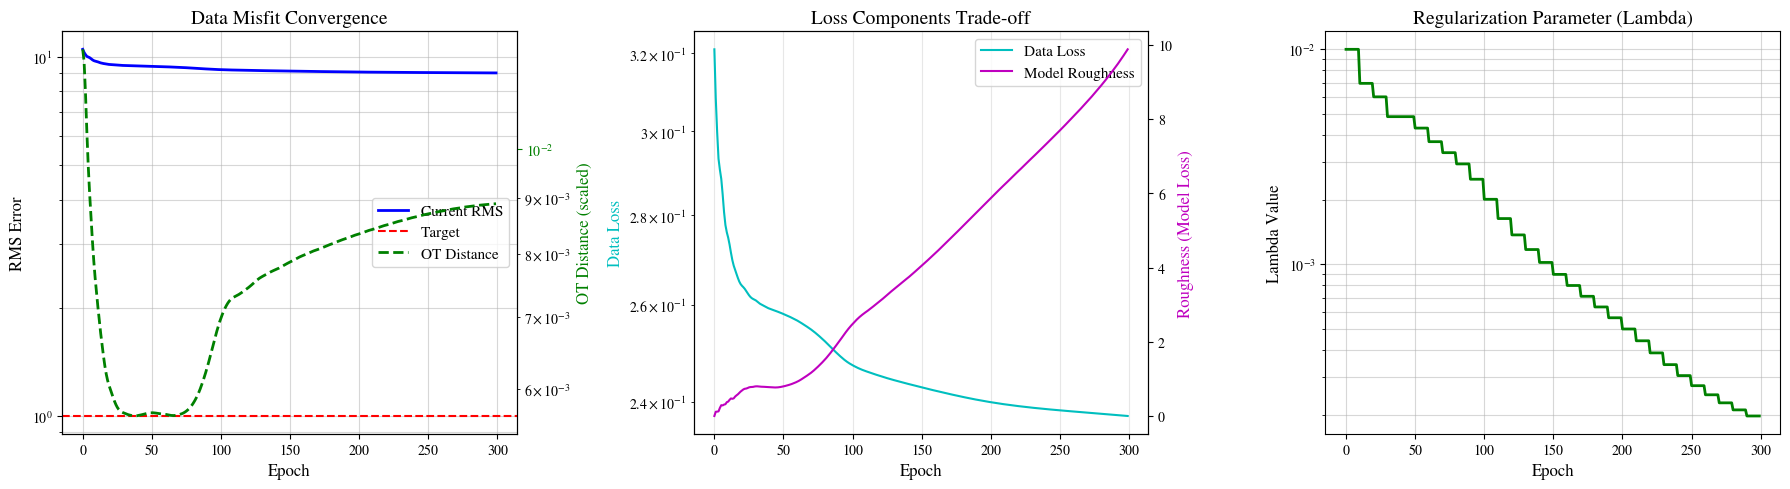

Model structural similarity (SSIM): 0.8959


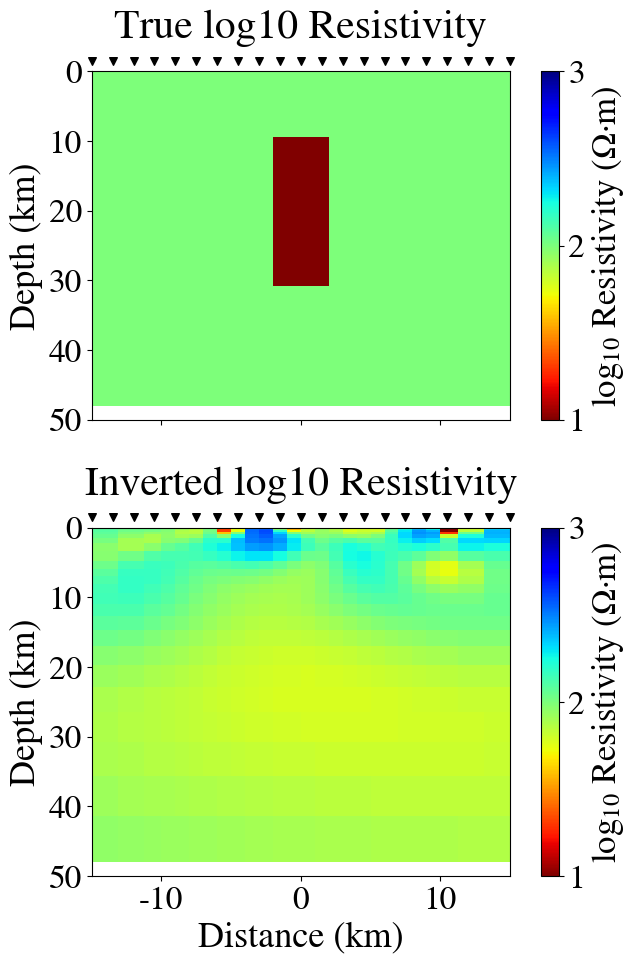

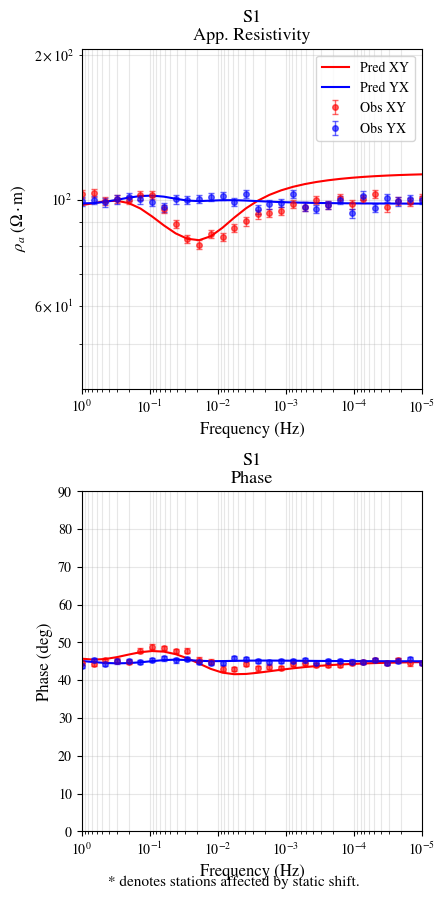

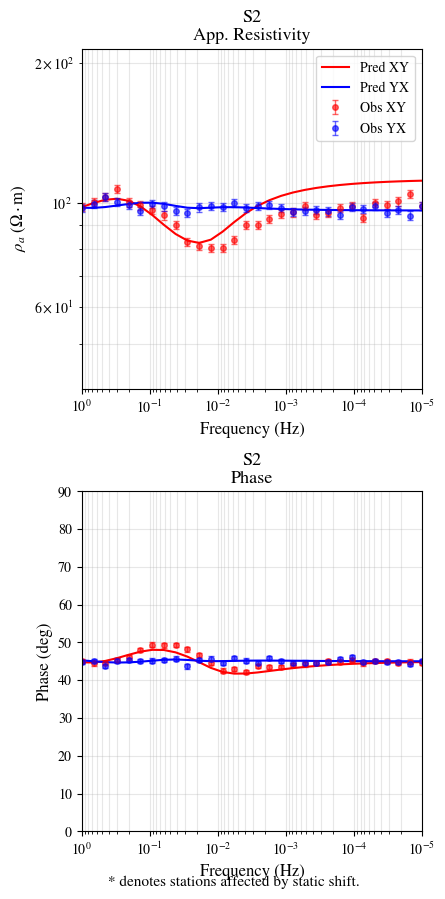

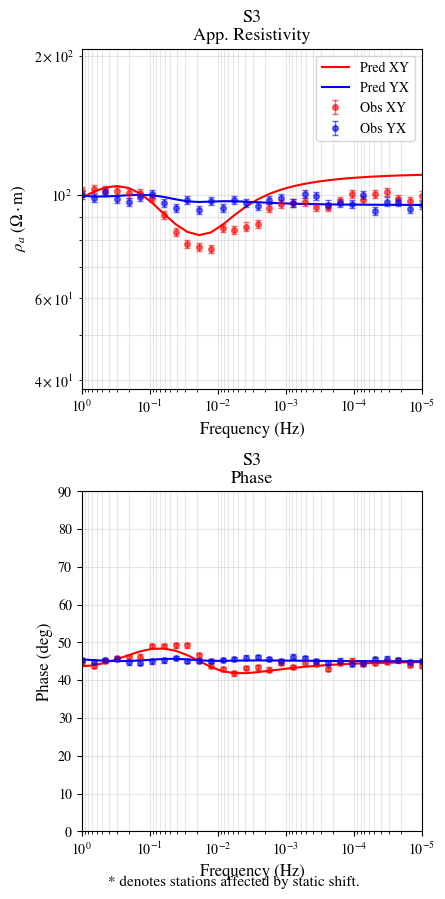

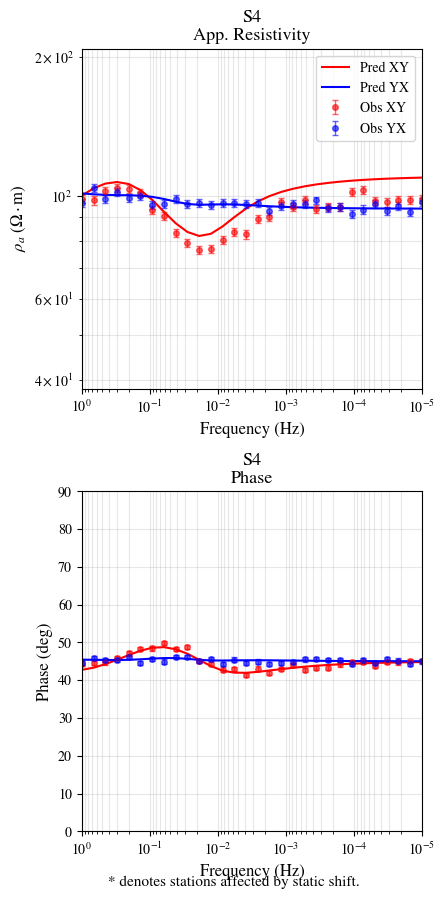

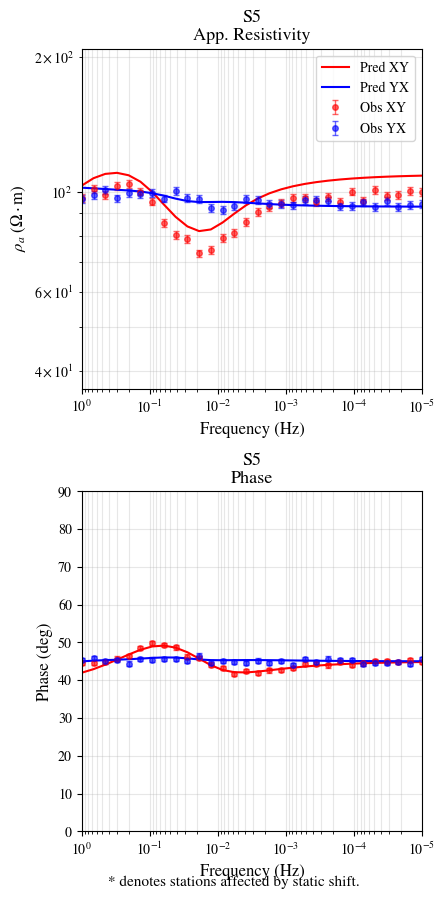

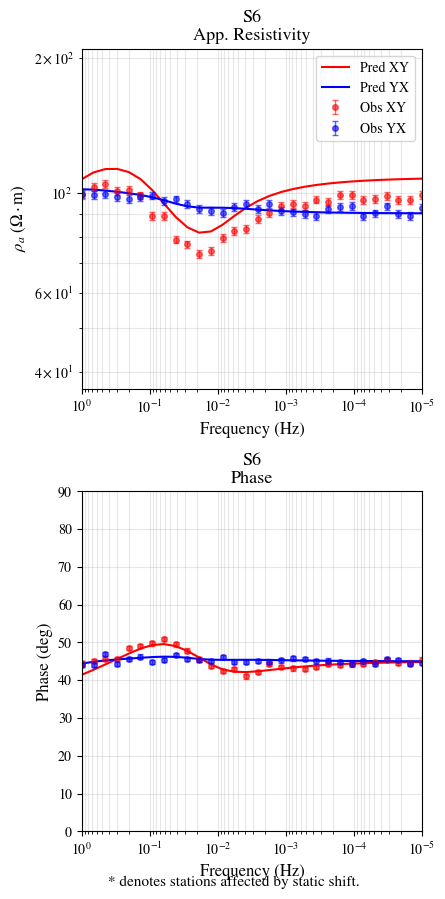

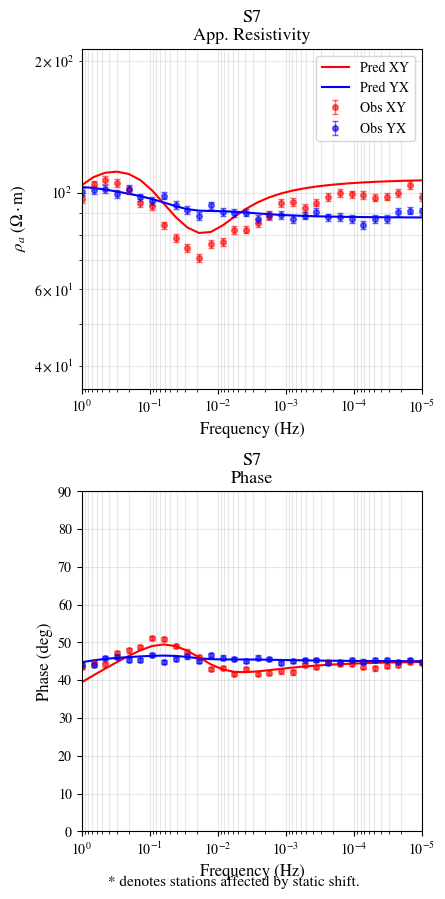

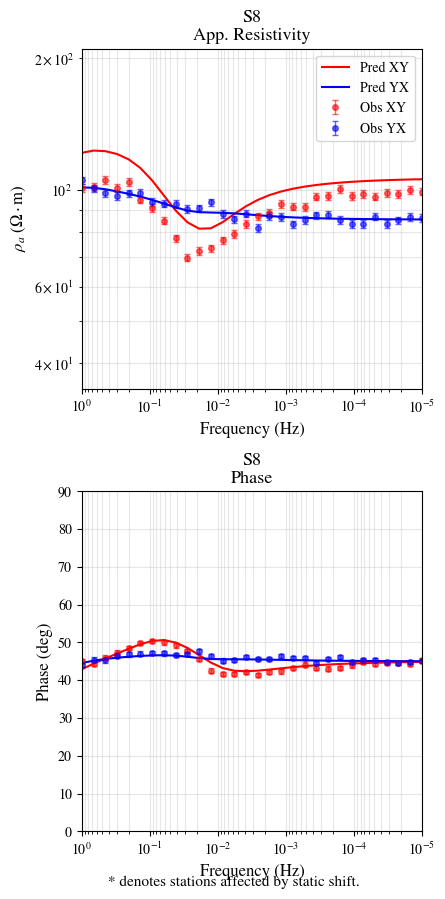

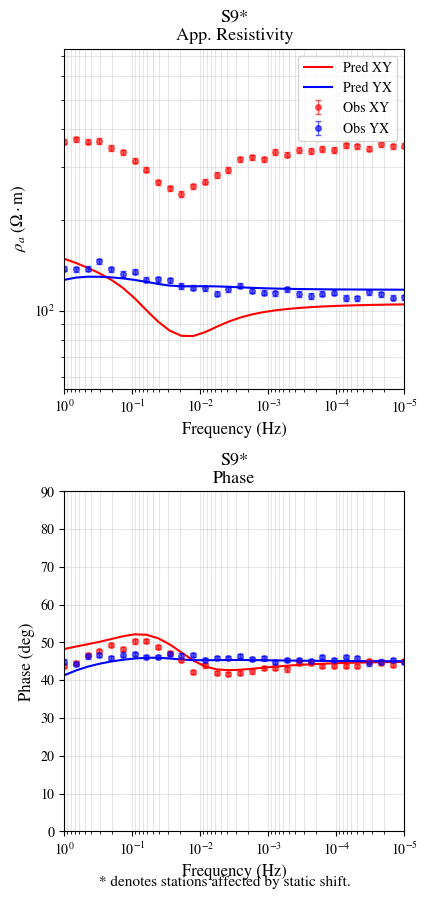

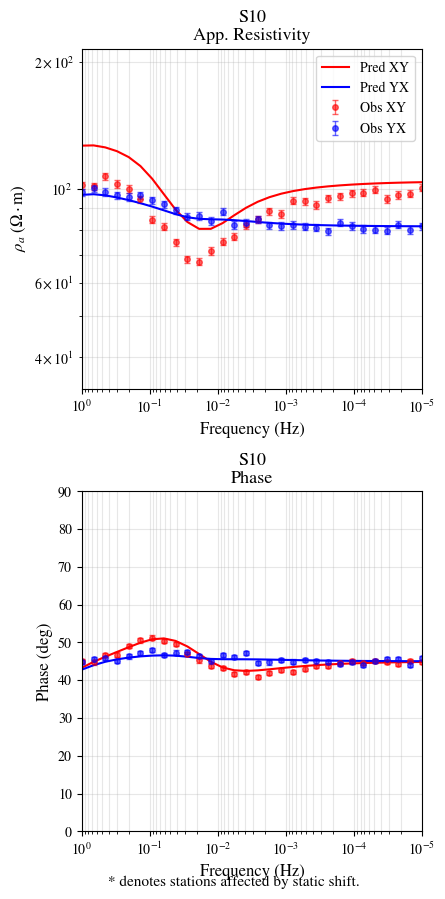

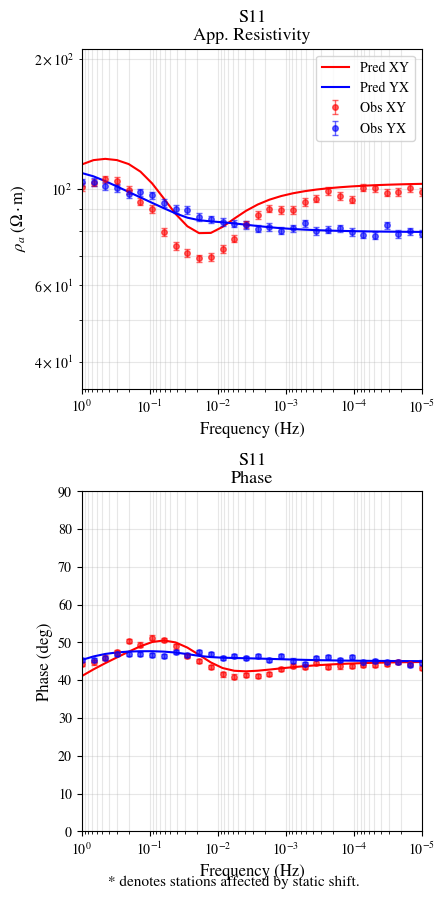

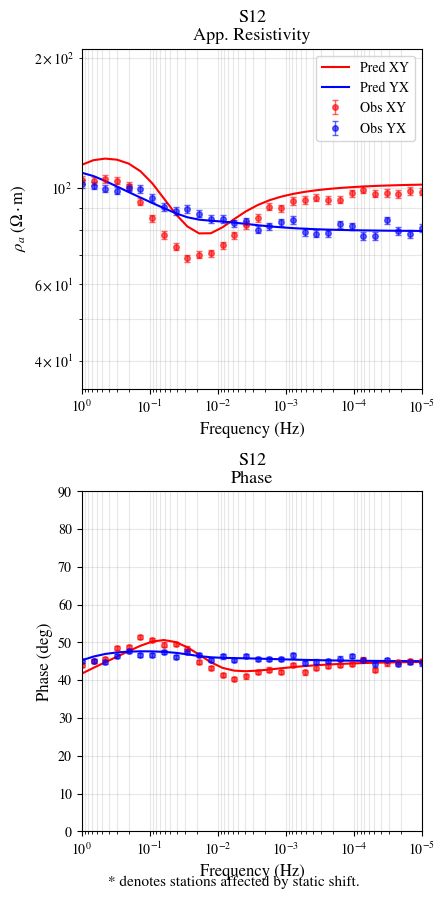

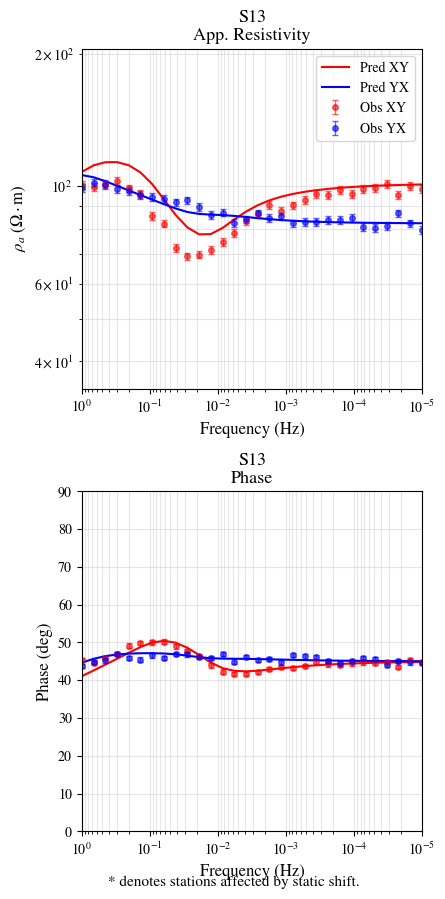

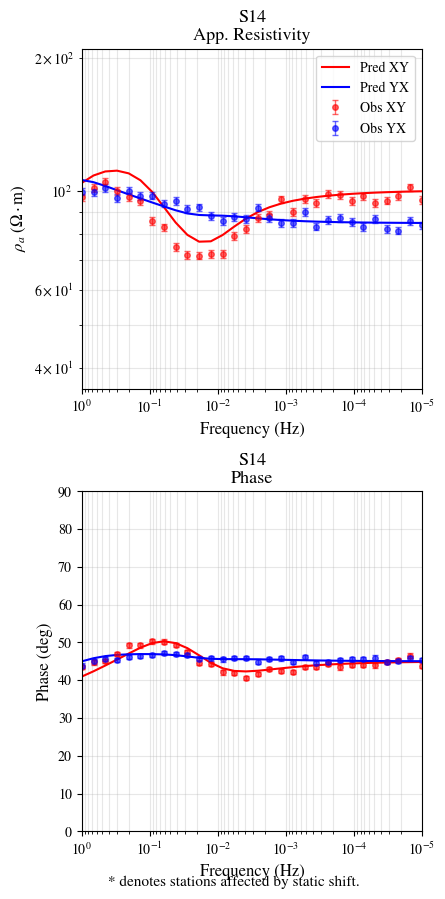

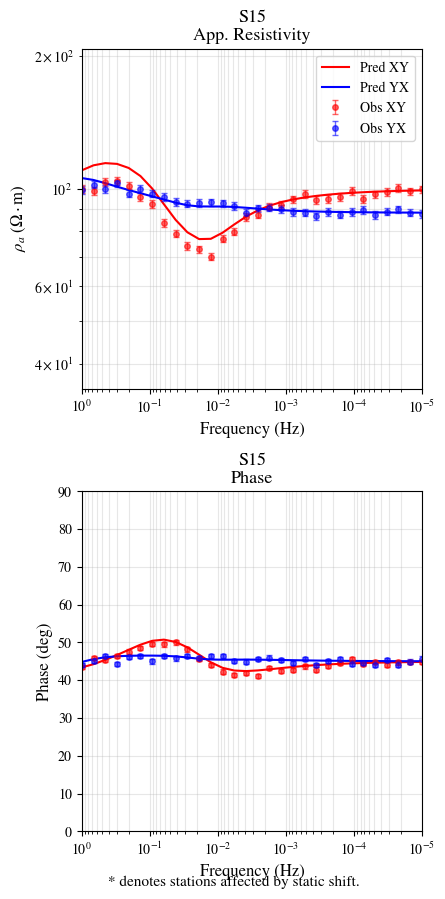

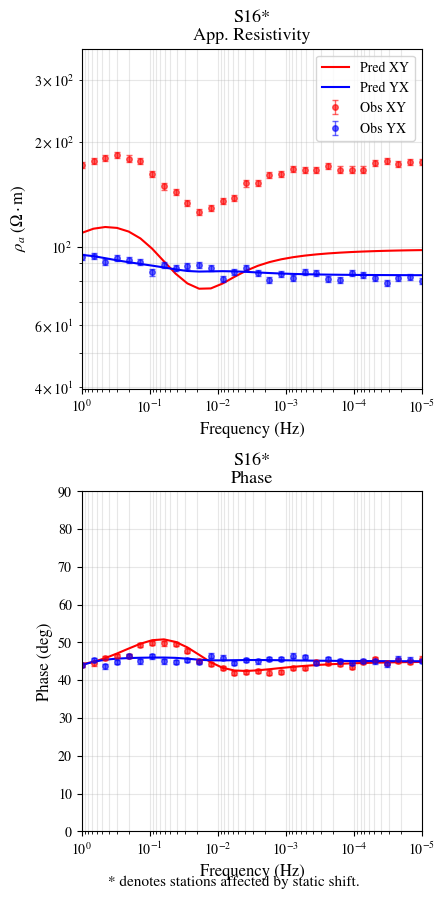

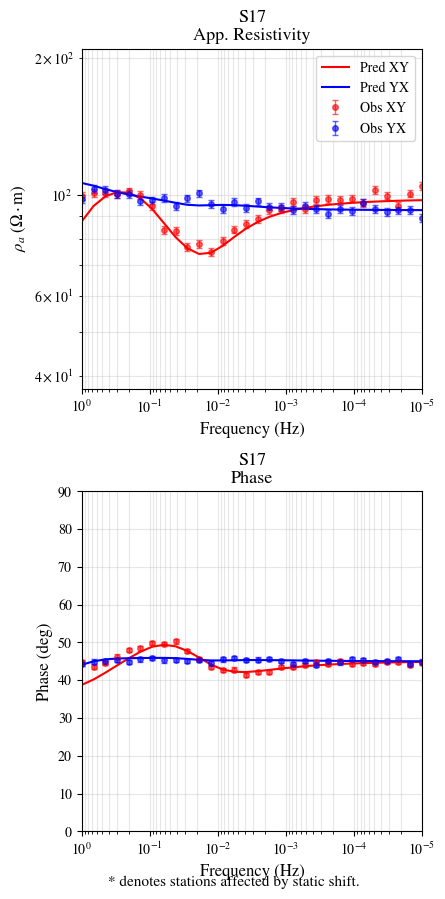

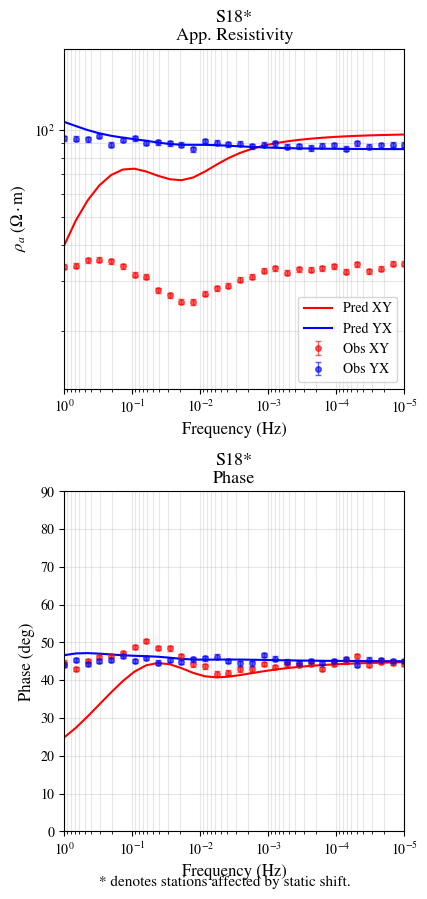

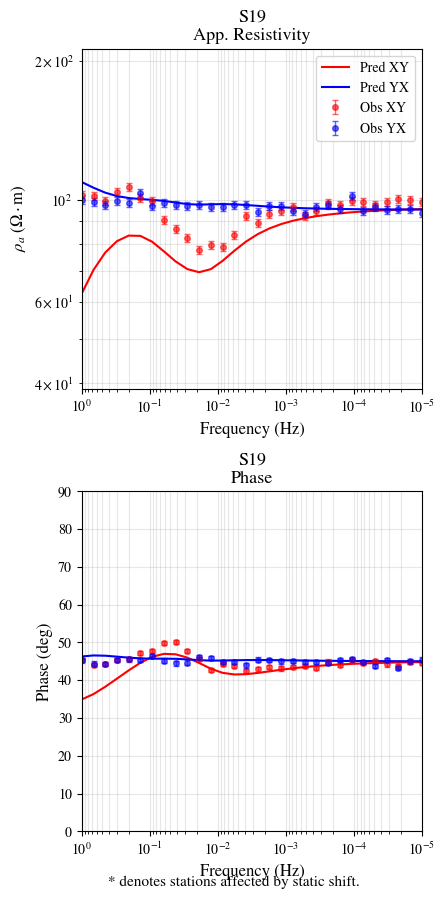

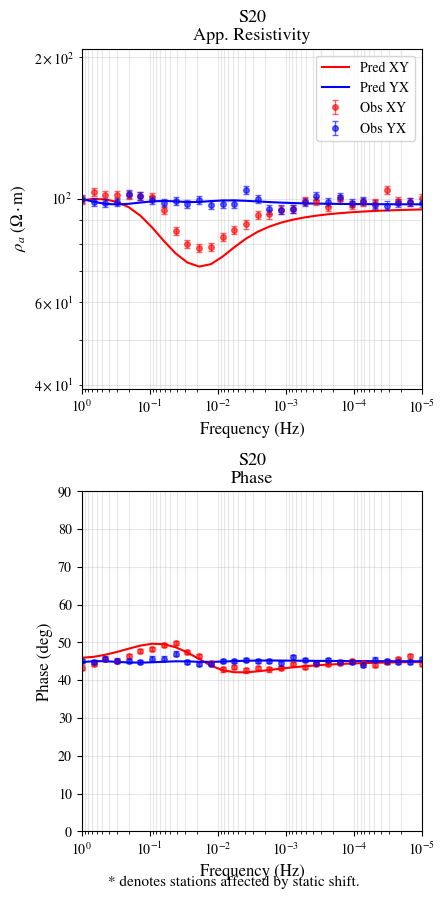

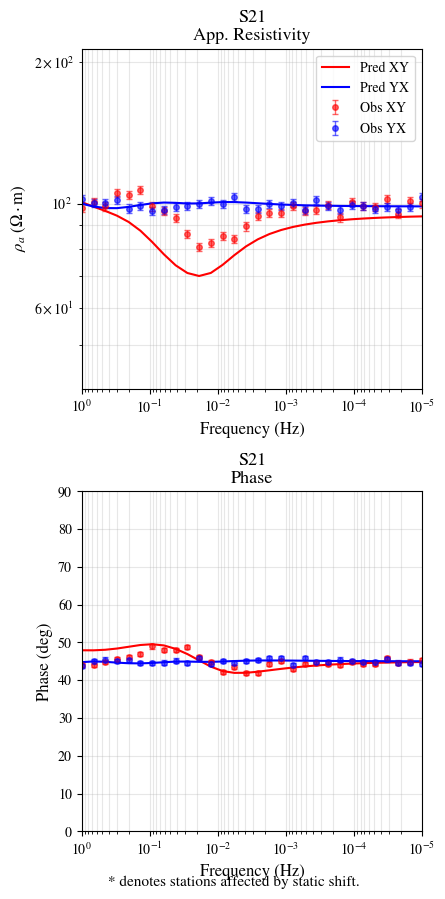

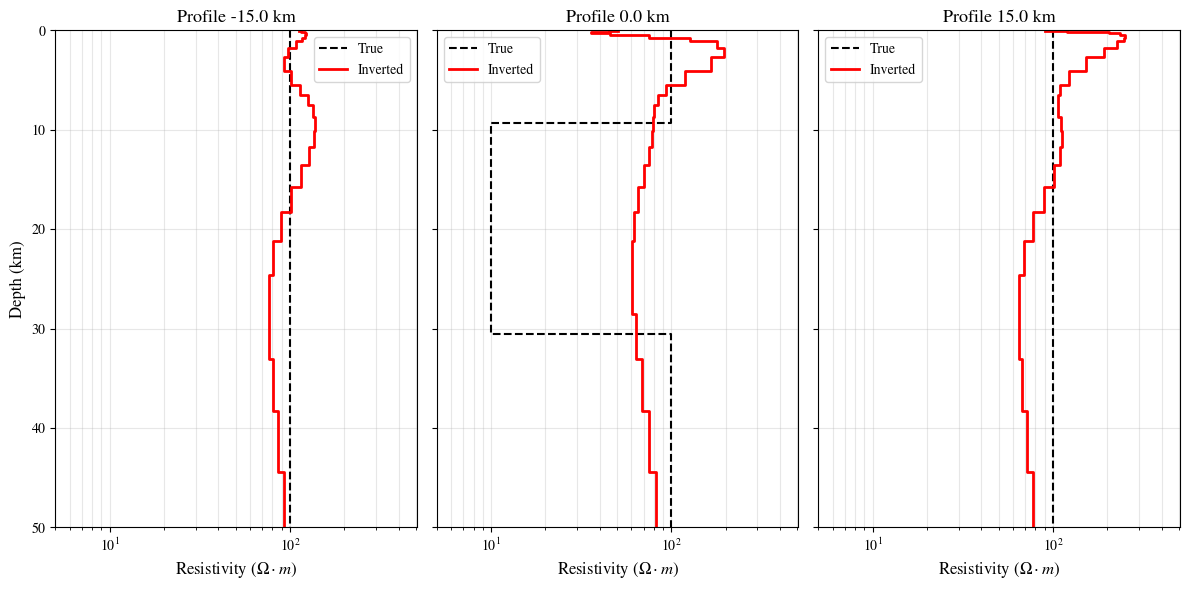

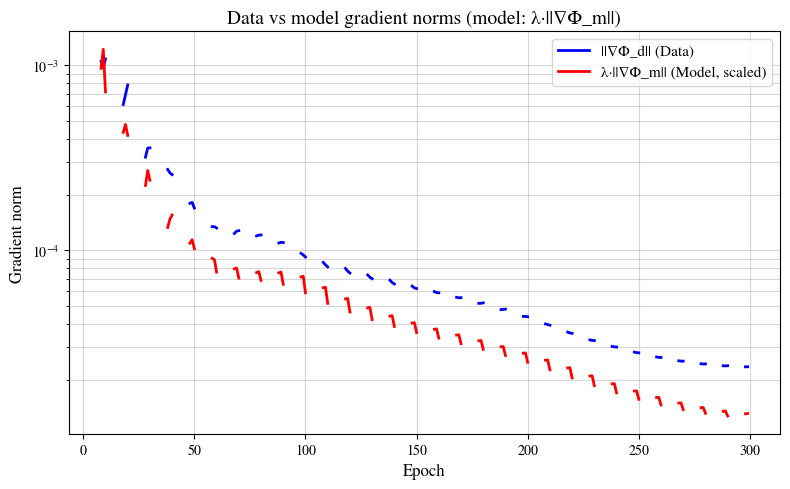

In [9]:
# 5b) MSE 结果绘图
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)
inv.plot_data_fitting()
inv.plot_1d_profiles(depth_limit_km=50)
inv.plot_gradient_history()

In [10]:
# 6b) 保存 MSE 结果
mse_run_dir = logger.save_from_inverter(inv, run_name="mse_21_1shift0.15")
history_mse = list(inv.loss_history)
print(f"MSE run saved: {mse_run_dir}")


Saving results to: test_results/ccmm2d1/2026-07-06_13-14-58_mse_21_1shift0.15
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz
Model structural similarity (SSIM): 0.8959


/home/liuxr/MTinv_OT3/src/mt2d_inv/plotting/inversion.py:682: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


  ✓ data_fitting: 21 plots saved to test_results/ccmm2d1/2026-07-06_13-14-58_mse_21_1shift0.15/figures/data_fitting (21 stations)
  ✓ Figures saved to test_results/ccmm2d1/2026-07-06_13-14-58_mse_21_1shift0.15/figures

Results saved successfully!
  Location: test_results/ccmm2d1/2026-07-06_13-14-58_mse_21_1shift0.15
  Final RMS χ²: 9.0050
  RMSE: 0.2452
  MAPE: 9.40%

MSE run saved: test_results/ccmm2d1/2026-07-06_13-14-58_mse_21_1shift0.15


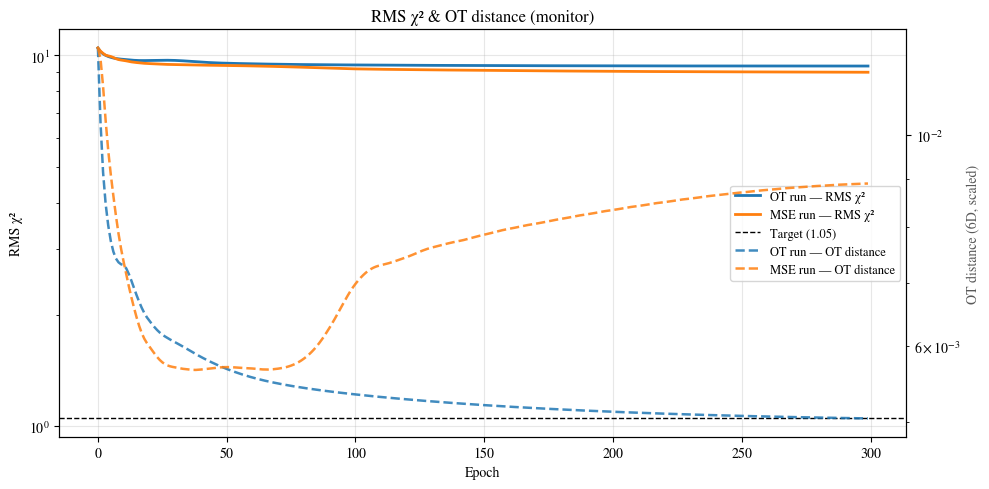

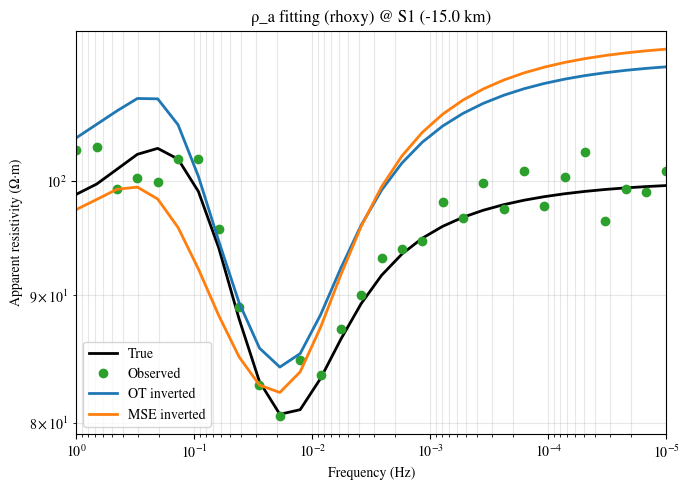

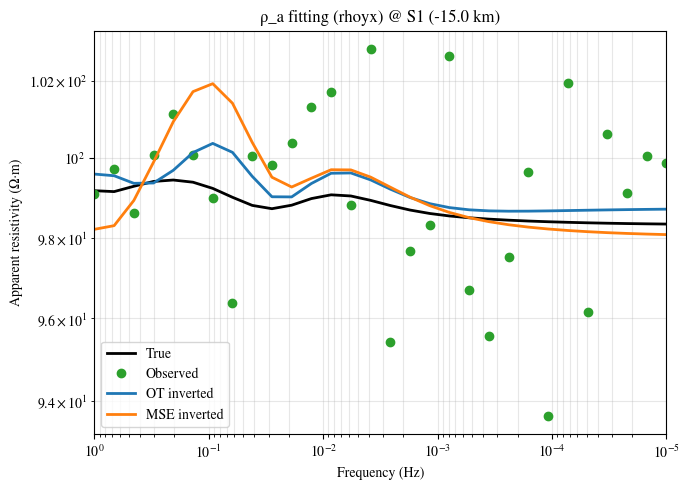

/home/liuxr/MTinv_OT3/src/mt2d_inv/plotting/pseudosection.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


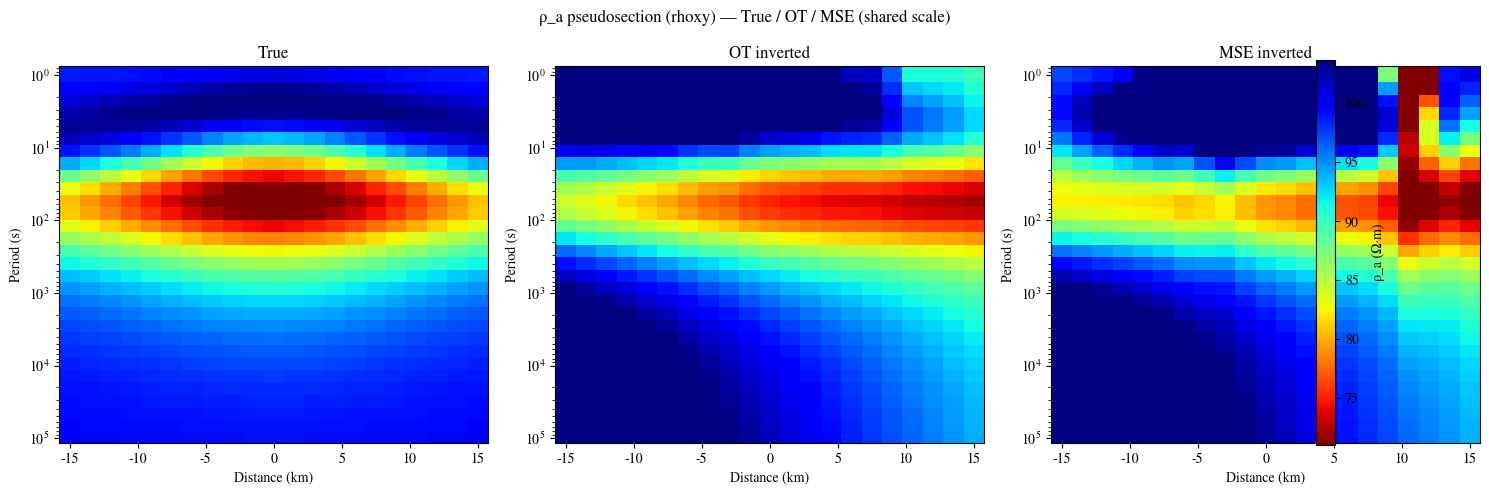

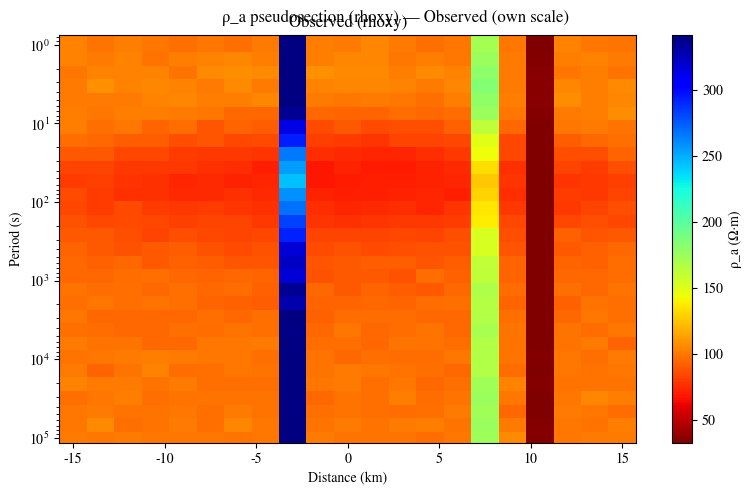

{'inversion_axes': array([[<Axes: title={'center': 'True'}, xlabel='Distance (km)', ylabel='Period (s)'>,
         <Axes: title={'center': 'OT inverted'}, xlabel='Distance (km)', ylabel='Period (s)'>,
         <Axes: title={'center': 'MSE inverted'}, xlabel='Distance (km)', ylabel='Period (s)'>]],
       dtype=object),
 'observed_axes': <Axes: title={'center': 'Observed (rhoxy)'}, xlabel='Distance (km)', ylabel='Period (s)'>}

In [11]:
# 7) OT vs MSE 对比（收敛曲线 + 视电阻率四线合一 + 伪断面）
plot_ot_mse_convergence(history_ot, history_mse, target_misfit=1.05)

plot_rho_fitting_from_npz(
    ot_run_dir / "apparent_resistivity.npz",
    mse_run_dir / "apparent_resistivity.npz",
    station_idx=0,
    mode="xy",
)
plot_rho_fitting_from_npz(
    ot_run_dir / "apparent_resistivity.npz",
    mse_run_dir / "apparent_resistivity.npz",
    station_idx=0,
    mode="yx",
)

plot_ot_mse_pseudosection_from_npz(
    ot_run_dir / "apparent_resistivity.npz",
    mse_run_dir / "apparent_resistivity.npz",
    mode="xy",
)